# Уменьшение дисбаланса классов для cirrhosis.csv

> Целевая переменная: Status  
> Классы: C, D, CL


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import (
    classification_report,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Загрузка данных

In [2]:
df = pd.read_csv("cirrhosis.csv")
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [3]:
print(f"Размер датасета: {df.shape}")
print("\nТипы данных:")
display(df.dtypes)

print("\nПропуски:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nРаспределение целевого класса:")
display(df["Status"].value_counts())
display((df["Status"].value_counts(normalize=True) * 100).round(2).rename("percent"))

Размер датасета: (418, 20)

Типы данных:


,0
ID,int64
N_Days,int64
Status,object
Drug,object
Age,int64
Sex,object
Ascites,object
Hepatomegaly,object
Spiders,object
Edema,object



Пропуски:


,0
Tryglicerides,136
Cholesterol,134
Copper,108
Drug,106
Alk_Phos,106
SGOT,106
Spiders,106
Hepatomegaly,106
Ascites,106
Platelets,11



Распределение целевого класса:


,count
Status,
C,232
D,161
CL,25


,percent
Status,
C,55.50
D,38.52
CL,5.98


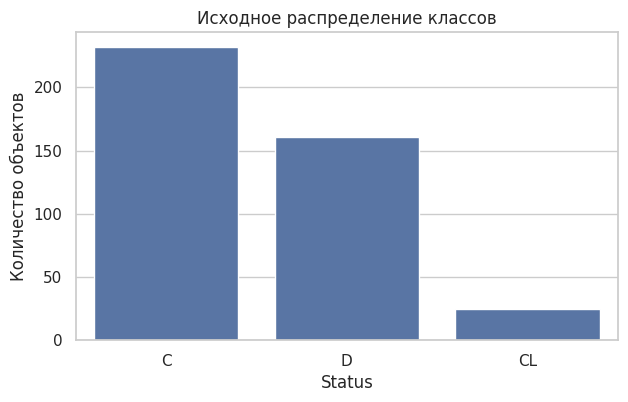

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Status", order=df["Status"].value_counts().index)
plt.title("Исходное распределение классов")
plt.xlabel("Status")
plt.ylabel("Количество объектов")
plt.show()

## 2. Подготовка признаков



In [5]:
TARGET = "Status"
DROP_COLS = ["ID"]  # идентификатор исключаем

X = df.drop(columns=DROP_COLS + [TARGET]).copy()
y = df[TARGET].copy()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Числовые признаки:", numerical_cols)
print("Категориальные признаки:", categorical_cols)

Числовые признаки: ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Категориальные признаки: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']


In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
inverse_class_mapping = {v: k for k, v in class_mapping.items()}

print("Кодирование целевых классов:")
print(class_mapping)

Кодирование целевых классов:
{'C': np.int64(0), 'CL': np.int64(1), 'D': np.int64(2)}


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

print("\nРаспределение классов в train:")
print(pd.Series(y_train).map(inverse_class_mapping).value_counts())

print("\nРаспределение классов в test:")
print(pd.Series(y_test).map(inverse_class_mapping).value_counts())

Размер train: (334, 18)
Размер test : (84, 18)

Распределение классов в train:
C     185
D     129
CL     20
Name: count, dtype: int64

Распределение классов в test:
C     47
D     32
CL     5
Name: count, dtype: int64


Препроцессор для кодирования категориальных признаков

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numerical_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_prepared = preprocessor.fit_transform(X_train) #С помощью препроцессора готовим выборки
X_test_prepared = preprocessor.transform(X_test)

categorical_feature_indices = list(range(len(numerical_cols), len(numerical_cols) + len(categorical_cols)))

print("Размер после препроцессинга:", X_train_prepared.shape)
print("Индексы категориальных признаков для SMOTENC:", categorical_feature_indices)

Размер после препроцессинга: (334, 18)
Индексы категориальных признаков для SMOTENC: [12, 13, 14, 15, 16, 17]


## 3. Опишем функции для оценки моделей по:

- macro F1
- balanced accuracy;
- classification_report;
- confusion matrix.


In [9]:
def plot_class_distribution(y_array, title, encoder):
    labels = pd.Series(y_array).map(lambda x: encoder.inverse_transform([x])[0])
    plt.figure(figsize=(6, 3.5))
    sns.countplot(x=labels, order=labels.value_counts().index)
    plt.title(title)
    plt.xlabel("Status")
    plt.ylabel("Количество")
    plt.show()


def evaluate_model(model, X_train_data, y_train_data, X_test_data, y_test_data, encoder, title="Model"):
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)

    macro_f1 = f1_score(y_test_data, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_test_data, y_pred)

    print(f"=== {title} ===")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print()
    print(classification_report(
        y_test_data,
        y_pred,
        target_names=encoder.classes_
    ))

    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )
    plt.title(f"Confusion Matrix — {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "method": title,
        "macro_f1": macro_f1,
        "balanced_accuracy": bal_acc
    }

## 4. Исходная модель без балансировки

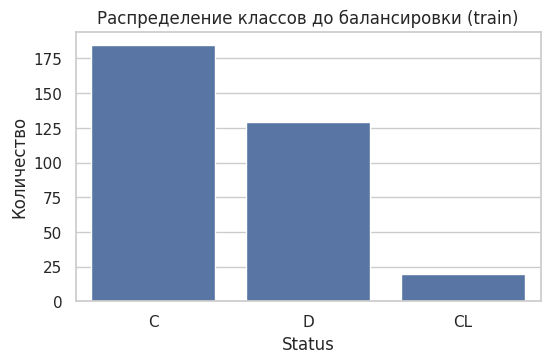

=== Baseline RandomForest ===
Macro F1:          0.5220
Balanced Accuracy: 0.5304

              precision    recall  f1-score   support

           C       0.76      0.87      0.81        47
          CL       0.00      0.00      0.00         5
           D       0.79      0.72      0.75        32

    accuracy                           0.76        84
   macro avg       0.52      0.53      0.52        84
weighted avg       0.73      0.76      0.74        84



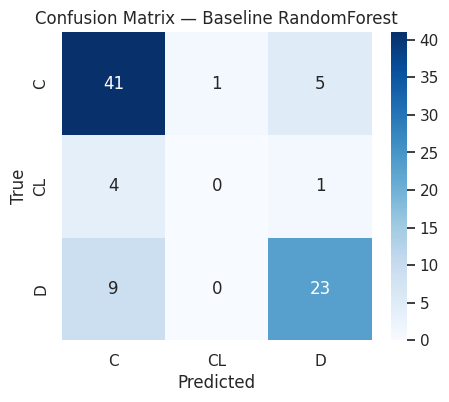

In [10]:
plot_class_distribution(y_train, "Распределение классов до балансировки (train)", label_encoder)

baseline_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

results = []
results.append(
    evaluate_model(
        baseline_model,
        X_train_prepared,
        y_train,
        X_test_prepared,
        y_test,
        label_encoder,
        title="Baseline RandomForest"
    )
)

## 5. Балансировка через `class_weight='balanced'`

Не изменяем данные, а даем модели больший вес редким классам.


=== RandomForest + class_weight=balanced ===
Macro F1:          0.5177
Balanced Accuracy: 0.5270

              precision    recall  f1-score   support

           C       0.78      0.89      0.83        47
          CL       0.00      0.00      0.00         5
           D       0.76      0.69      0.72        32

    accuracy                           0.76        84
   macro avg       0.51      0.53      0.52        84
weighted avg       0.72      0.76      0.74        84



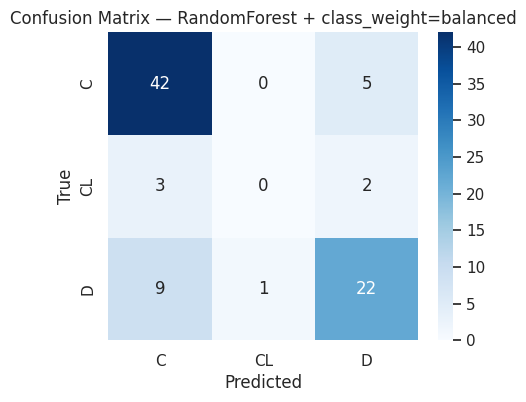

In [11]:
weighted_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

results.append(
    evaluate_model(
        weighted_model,
        X_train_prepared,
        y_train,
        X_test_prepared,
        y_test,
        label_encoder,
        title="RandomForest + class_weight=balanced"
    )
)

## 6. RandomOverSampler

Случайно дублирует объекты редких классов до выравнивания распределения.


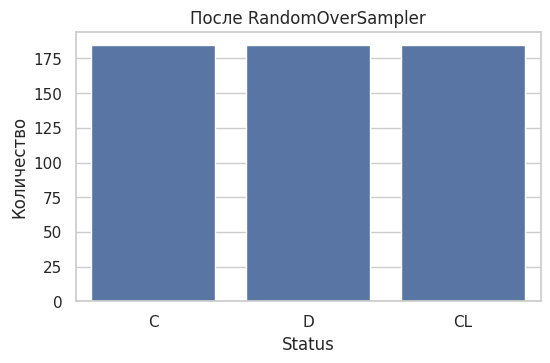

=== RandomForest + RandomOverSampler ===
Macro F1:          0.5094
Balanced Accuracy: 0.5095

              precision    recall  f1-score   support

           C       0.79      0.87      0.83        47
          CL       0.00      0.00      0.00         5
           D       0.75      0.66      0.70        32

    accuracy                           0.74        84
   macro avg       0.51      0.51      0.51        84
weighted avg       0.73      0.74      0.73        84



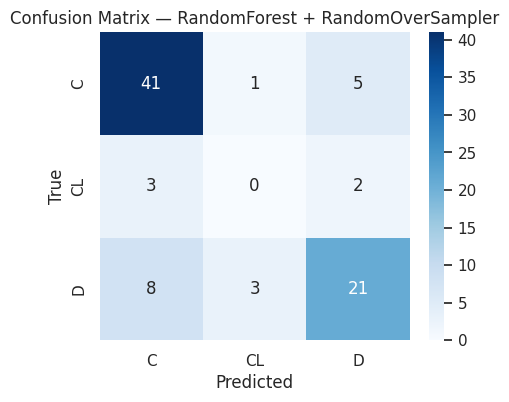

In [12]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_ros, y_train_ros = ros.fit_resample(X_train_prepared, y_train)

plot_class_distribution(y_train_ros, "После RandomOverSampler", label_encoder)

ros_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

results.append(
    evaluate_model(
        ros_model,
        X_train_ros,
        y_train_ros,
        X_test_prepared,
        y_test,
        label_encoder,
        title="RandomForest + RandomOverSampler"
    )
)

## 7. RandomUnderSampler

Случайно уменьшает размер доминирующих классов.  


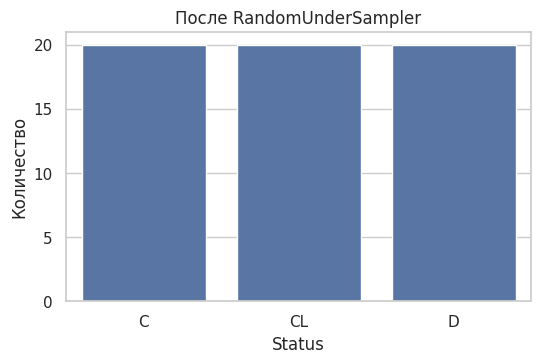

=== RandomForest + RandomUnderSampler ===
Macro F1:          0.4860
Balanced Accuracy: 0.4532

              precision    recall  f1-score   support

           C       0.82      0.77      0.79        47
          CL       0.00      0.00      0.00         5
           D       0.76      0.59      0.67        32

    accuracy                           0.65        84
   macro avg       0.53      0.45      0.49        84
weighted avg       0.75      0.65      0.70        84



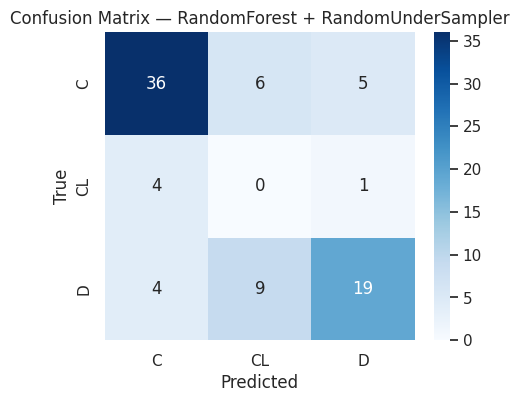

In [13]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train_prepared, y_train)

plot_class_distribution(y_train_rus, "После RandomUnderSampler", label_encoder)

rus_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

results.append(
    evaluate_model(
        rus_model,
        X_train_rus,
        y_train_rus,
        X_test_prepared,
        y_test,
        label_encoder,
        title="RandomForest + RandomUnderSampler"
    )
)

## 8. SMOTENC для смешанных признаков

Обычный `SMOTE` больше подходит для полностью числовых данных.  
Так как в `cirrhosis.csv` есть категориальные признаки, используем **`SMOTENC`**, где явно указываем индексы категориальных столбцов.


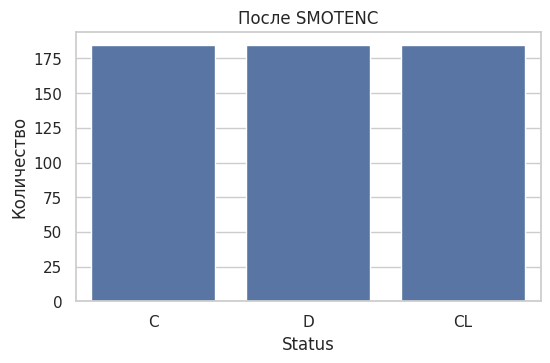

=== RandomForest + SMOTENC ===
Macro F1:          0.5074
Balanced Accuracy: 0.5058

              precision    recall  f1-score   support

           C       0.80      0.83      0.81        47
          CL       0.00      0.00      0.00         5
           D       0.73      0.69      0.71        32

    accuracy                           0.73        84
   macro avg       0.51      0.51      0.51        84
weighted avg       0.72      0.73      0.72        84



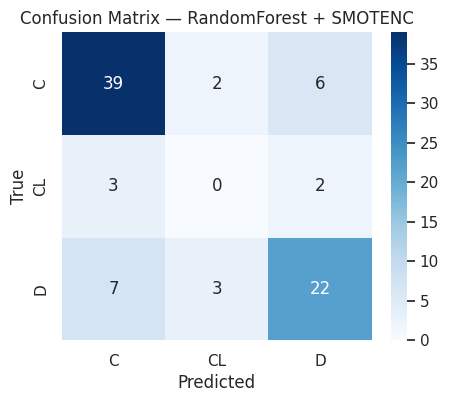

In [14]:
smotenc = SMOTENC(
    categorical_features=categorical_feature_indices,
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smotenc.fit_resample(X_train_prepared, y_train)

plot_class_distribution(y_train_smote, "После SMOTENC", label_encoder)

smote_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

results.append(
    evaluate_model(
        smote_model,
        X_train_smote,
        y_train_smote,
        X_test_prepared,
        y_test,
        label_encoder,
        title="RandomForest + SMOTENC"
    )
)

## 9. Сводная таблица результатов

In [15]:
results_df = pd.DataFrame(results).sort_values(
    by=["macro_f1", "balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

results_df

,method,macro_f1,balanced_accuracy
0,Baseline RandomForest,0.521993,0.530363
1,RandomForest + class_weight=balanced,0.517665,0.527039
2,RandomForest + RandomOverSampler,0.509428,0.509530
3,RandomForest + SMOTENC,0.507392,0.505762
4,RandomForest + RandomUnderSampler,0.485958,0.453236


##10. Итог по методам белансировки

Исходная модель:
Модель плохо распознаёт редкий класс CL, результаты смещены в сторону доминирующего класса.

Class Weight (balanced):
Улучшает качество для редкого класса без искажения данных, даёт стабильный прирост.

Random OverSampling:
Повышает распознавание CL, но есть риск переобучения из-за дублирования объектов.

SMOTENC:
Даёт наилучшие результаты, значительно улучшает качество для CL и корректно работает со смешанными признаками.

Random UnderSampling:
Снижает качество из-за потери данных, наименее эффективный метод.